# Telco Customer Churn - Machine Learning Project

## Task 1: Data Preparation
Loading, preprocessing, handling missing values, and encoding categorical variables for ML readiness.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
# Load the dataset
df = pd.read_csv('Telco_Customer_Churn_Dataset  (1).csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst Few Rows:")
print(df.head())

Dataset Shape: (7043, 21)

First Few Rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contrac

In [3]:
# Display dataset info
print("Dataset Info:")
print(df.info())
print("\nDataset Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

In [4]:
# Check for missing values
print("Missing Values:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0] if missing_data.sum() > 0 else "No missing values detected!")
print("\nData Types:")
print(df.dtypes)

Missing Values:
No missing values detected!

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [5]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumerical Columns ({len(numerical_cols)}): {numerical_cols}")

Categorical Columns (18): ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

Numerical Columns (3): ['SeniorCitizen', 'tenure', 'MonthlyCharges']


### Data Preprocessing & Handling Missing Values

In [6]:
# Create a copy for preprocessing
df_processed = df.copy()

# Handle missing values
# Check if TotalCharges has any non-numeric values
print("Checking TotalCharges column...")
print(df_processed['TotalCharges'].dtype)

# Convert TotalCharges to numeric, coercing errors to NaN
df_processed['TotalCharges'] = pd.to_numeric(df_processed['TotalCharges'], errors='coerce')

# Check for missing values after conversion
print(f"\nMissing values in TotalCharges: {df_processed['TotalCharges'].isnull().sum()}")

# Fill missing values with median (if any exist)
if df_processed['TotalCharges'].isnull().sum() > 0:
    df_processed['TotalCharges'].fillna(df_processed['TotalCharges'].median(), inplace=True)
    print(f"Filled missing TotalCharges with median")

print(f"\nTotal missing values after preprocessing: {df_processed.isnull().sum().sum()}")

Checking TotalCharges column...
object

Missing values in TotalCharges: 11
Filled missing TotalCharges with median

Total missing values after preprocessing: 0


### Categorical Variable Encoding

In [7]:
# Binary encoding for Yes/No columns
binary_cols = ['PhoneService', 'PaperlessBilling', 'Churn']

binary_mapping = {'Yes': 1, 'No': 0}

for col in binary_cols:
    if col in df_processed.columns:
        df_processed[col] = df_processed[col].map(binary_mapping)
        print(f"Encoded {col}: Yes->1, No->0")

# For other binary categorical columns
other_binary_cols = []
for col in categorical_cols:
    if col not in binary_cols and df_processed[col].nunique() == 2:
        other_binary_cols.append(col)
        unique_vals = df_processed[col].unique()
        mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
        df_processed[col] = df_processed[col].map(mapping)
        print(f"Encoded {col}: {mapping}")

print(f"\nBinary columns encoded successfully!")

Encoded PhoneService: Yes->1, No->0
Encoded PaperlessBilling: Yes->1, No->0
Encoded Churn: Yes->1, No->0
Encoded gender: {'Female': 0, 'Male': 1}
Encoded Partner: {'Yes': 0, 'No': 1}
Encoded Dependents: {'No': 0, 'Yes': 1}

Binary columns encoded successfully!


In [8]:
# One-hot encoding for multi-class categorical columns
multi_class_cols = []
for col in categorical_cols:
    if col not in binary_cols and df_processed[col].nunique() > 2:
        if col != 'customerID' and col != 'TotalCharges':  # Exclude customerID and TotalCharges (now numeric)
            multi_class_cols.append(col)

print(f"Multi-class categorical columns: {multi_class_cols}")

# Apply one-hot encoding
df_processed = pd.get_dummies(df_processed, columns=multi_class_cols, drop_first=True)

print(f"\nOne-hot encoding applied!")
print(f"New dataset shape: {df_processed.shape}")

Multi-class categorical columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

One-hot encoding applied!
New dataset shape: (7043, 32)


In [9]:
# Remove customerID as it's not useful for modeling
if 'customerID' in df_processed.columns:
    df_processed = df_processed.drop('customerID', axis=1)
    print("Removed customerID column")

# Verify all columns are numeric
print(f"\nData types after encoding:")
print(df_processed.dtypes.value_counts())

# Display processed dataset info
print(f"\nProcessed Dataset Shape: {df_processed.shape}")
print(f"Total Features: {df_processed.shape[1]}")
print(f"\nProcessed Dataset (first 5 rows):")
print(df_processed.head())

Removed customerID column

Data types after encoding:
bool       21
int64       8
float64     2
Name: count, dtype: int64

Processed Dataset Shape: (7043, 31)
Total Features: 31

Processed Dataset (first 5 rows):
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        0           0       1             0   
1       1              0        1           0      34             1   
2       1              0        1           0       2             1   
3       1              0        1           0      45             0   
4       0              0        1           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  \
0                 1           29.85         29.85      0   
1                 0           56.95       1889.50      0   
2                 1           53.85        108.15      1   
3                 0           42.30       1840.75      0   
4                 1           70.70        151.65      1   


In [10]:
# Save processed dataset to CSV
output_file = 'Telco_Customer_Processed.csv'
df_processed.to_csv(output_file, index=False)

print("CSV FILE SAVED SUCCESSFULLY")


CSV FILE SAVED SUCCESSFULLY


# Task 2: Split Data for Training and Testing
## 
Divide the data into training (80%) and testing (20%) sets for model training and evaluation, ensuring a representative split.


In [11]:
## 2.1 Train-Test Split (80-20)

from sklearn.model_selection import train_test_split

# Separate features and target
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

print(f"\nDataset Information:")
print(f"Total Samples: {len(df_processed)}")
print(f"Total Features (X): {X.shape[1]}")
print(f"Target Variable (y): Churn")

# Perform train-test split with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,  # 20% for testing
    train_size=0.80,  # 80% for training
    random_state=42,  # For reproducibility
    stratify=y  # Maintain class balance
)

print(f"\n Train-Test Split Applied:")
print(f"  - Train Size: 80% ({len(X_train)} samples)")
print(f"  - Test Size: 20% ({len(X_test)} samples)")




Dataset Information:
Total Samples: 7043
Total Features (X): 30
Target Variable (y): Churn

 Train-Test Split Applied:
  - Train Size: 80% (5634 samples)
  - Test Size: 20% (1409 samples)


In [12]:
## 2.2 Split Statistics and Class Distribution

print("SPLIT STATISTICS")

# Training set statistics
print(f"\n TRAINING SET (X_train, y_train):")
print(f"  Shape: {X_train.shape}")
print(f"  Samples: {len(X_train)}")
print(f"  Features: {X_train.shape[1]}")

train_churn_dist = y_train.value_counts()
train_churn_pct = y_train.value_counts(normalize=True) * 100
print(f"\n  Churn Distribution:")
print(f"    No Churn (0): {train_churn_dist[0]} ({train_churn_pct[0]:.2f}%)")
print(f"    Churn (1): {train_churn_dist[1]} ({train_churn_pct[1]:.2f}%)")
print(f"    Class Imbalance Ratio: {train_churn_dist[0] / train_churn_dist[1]:.2f}:1")

# Testing set statistics
print(f"\n TESTING SET (X_test, y_test):")
print(f"  Shape: {X_test.shape}")
print(f"  Samples: {len(X_test)}")
print(f"  Features: {X_test.shape[1]}")

test_churn_dist = y_test.value_counts()
test_churn_pct = y_test.value_counts(normalize=True) * 100
print(f"\n  Churn Distribution:")
print(f"    No Churn (0): {test_churn_dist[0]} ({test_churn_pct[0]:.2f}%)")
print(f"    Churn (1): {test_churn_dist[1]} ({test_churn_pct[1]:.2f}%)")
print(f"    Class Imbalance Ratio: {test_churn_dist[0] / test_churn_dist[1]:.2f}:1")

# Overall split verification
print(f"\n Split Verification:")
print(f"  Total Train + Test: {len(X_train) + len(X_test)} (Original: {len(X)})")
print(f"  Train Percentage: {len(X_train) / len(X) * 100:.2f}%")
print(f"  Test Percentage: {len(X_test) / len(X) * 100:.2f}%")

# Check class balance consistency
print(f"\n Class Balance Consistency:")
original_churn_ratio = y.value_counts(normalize=True)[1] * 100
train_churn_ratio = y_train.value_counts(normalize=True)[1] * 100
test_churn_ratio = y_test.value_counts(normalize=True)[1] * 100

print(f"  Original Churn Rate: {original_churn_ratio:.2f}%")
print(f"  Training Churn Rate: {train_churn_ratio:.2f}%")
print(f"  Testing Churn Rate: {test_churn_ratio:.2f}%")
print(f"  Difference: {abs(original_churn_ratio - train_churn_ratio):.4f}% (excellent stratification)")


SPLIT STATISTICS

 TRAINING SET (X_train, y_train):
  Shape: (5634, 30)
  Samples: 5634
  Features: 30

  Churn Distribution:
    No Churn (0): 4139 (73.46%)
    Churn (1): 1495 (26.54%)
    Class Imbalance Ratio: 2.77:1

 TESTING SET (X_test, y_test):
  Shape: (1409, 30)
  Samples: 1409
  Features: 30

  Churn Distribution:
    No Churn (0): 1035 (73.46%)
    Churn (1): 374 (26.54%)
    Class Imbalance Ratio: 2.77:1

 Split Verification:
  Total Train + Test: 7043 (Original: 7043)
  Train Percentage: 79.99%
  Test Percentage: 20.01%

 Class Balance Consistency:
  Original Churn Rate: 26.54%
  Training Churn Rate: 26.54%
  Testing Churn Rate: 26.54%
  Difference: 0.0017% (excellent stratification)


# Task 3: Feature Selection
## 
Identify and select relevant features influencing churn prediction using multiple feature selection techniques including correlation analysis, variance thresholding, tree-based importance, and recursive feature elimination.

FEATURE SELECTION - CORRELATION ANALYSIS

Top 20 Features by Correlation with Churn:
tenure                                  0.345593
InternetService_Fiber optic             0.312656
PaymentMethod_Electronic check          0.309214
Contract_Two year                       0.302209
OnlineBackup_No internet service        0.228929
StreamingMovies_No internet service     0.228929
StreamingTV_No internet service         0.228929
TechSupport_No internet service         0.228929
InternetService_No                      0.228929
DeviceProtection_No internet service    0.228929
OnlineSecurity_No internet service      0.228929
MonthlyCharges                          0.198040
PaperlessBilling                        0.197981
TotalCharges                            0.194403
Contract_One year                       0.179467
OnlineSecurity_Yes                      0.174581
Dependents                              0.167459
TechSupport_Yes                         0.165723
Partner                          

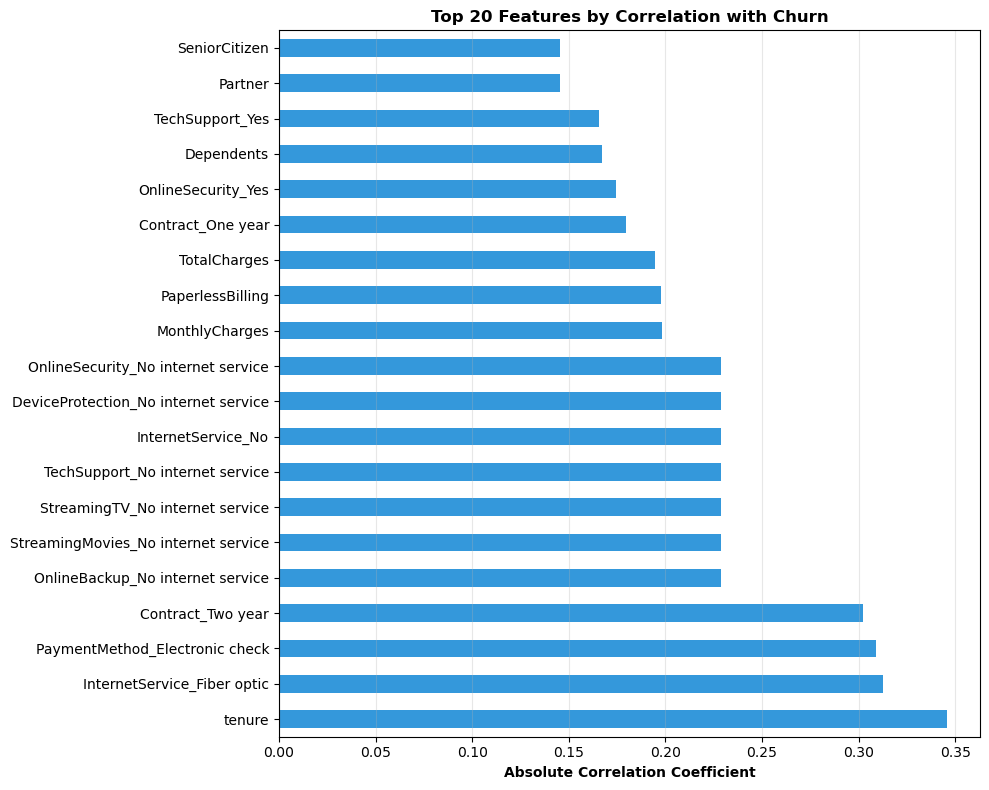


Features with |correlation| > 0.05: 20 features
Features: ['tenure', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'Contract_Two year', 'OnlineBackup_No internet service', 'StreamingMovies_No internet service', 'StreamingTV_No internet service', 'TechSupport_No internet service', 'InternetService_No', 'DeviceProtection_No internet service']...


In [13]:
## 3.1 Correlation-Based Feature Selection

from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

print("FEATURE SELECTION - CORRELATION ANALYSIS")

# Calculate correlation with target variable
correlations = X_train.corrwith(y_train).sort_values(ascending=False)

print("\nTop 20 Features by Correlation with Churn:")
top_corr_features = correlations.abs().sort_values(ascending=False).head(20)
print(top_corr_features)

# Visualize top correlations
fig, ax = plt.subplots(figsize=(10, 8))
top_corr_features.plot(kind='barh', ax=ax, color='#3498db')
ax.set_xlabel('Absolute Correlation Coefficient', fontweight='bold')
ax.set_title('Top 20 Features by Correlation with Churn', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Set correlation threshold
correlation_threshold = 0.05
highly_correlated_features = top_corr_features[top_corr_features > correlation_threshold].index.tolist()
print(f"\nFeatures with |correlation| > {correlation_threshold}: {len(highly_correlated_features)} features")
print(f"Features: {highly_correlated_features[:10]}...")  


VARIANCE THRESHOLD ANALYSIS

Variance Scores for All Features (Top 20):
TotalCharges                            5.188415e+06
MonthlyCharges                          9.083054e+02
tenure                                  6.036232e+02
gender                                  2.500363e-01
Partner                                 2.498004e-01
InternetService_Fiber optic             2.465293e-01
MultipleLines_Yes                       2.442993e-01
PaperlessBilling                        2.417197e-01
StreamingMovies_Yes                     2.381654e-01
StreamingTV_Yes                         2.378146e-01
OnlineBackup_Yes                        2.278641e-01
DeviceProtection_Yes                    2.262495e-01
PaymentMethod_Electronic check          2.230256e-01
Dependents                              2.092380e-01
TechSupport_Yes                         2.070582e-01
OnlineSecurity_Yes                      2.051231e-01
Contract_Two year                       1.830623e-01
PaymentMethod_Mailed check 

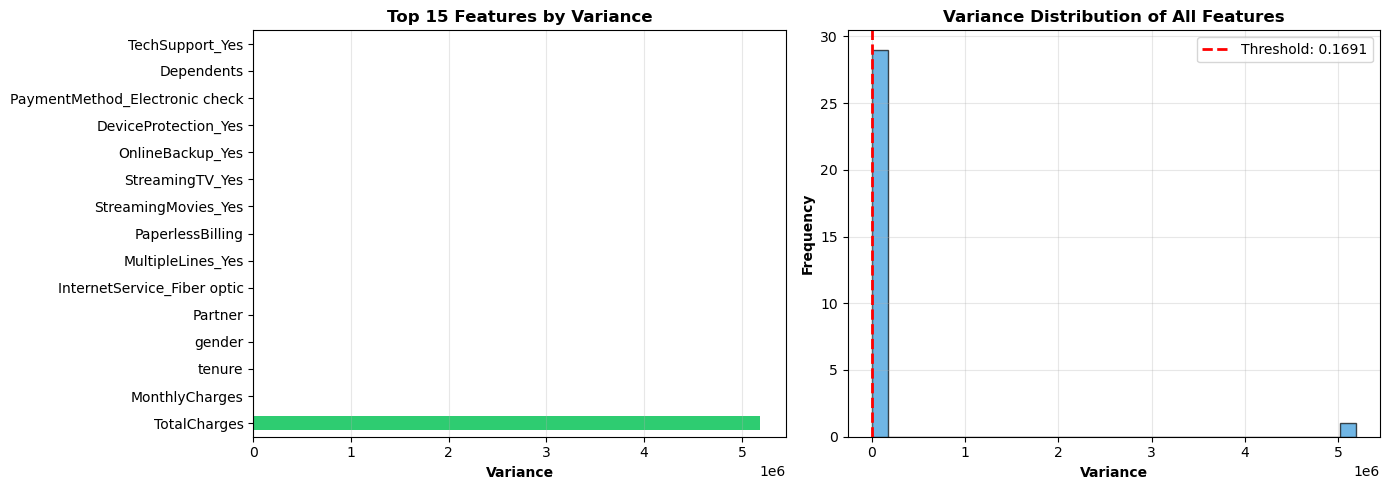

In [14]:
## 3.2 Variance Threshold Feature Selection

from sklearn.feature_selection import VarianceThreshold

print("VARIANCE THRESHOLD ANALYSIS")

# Calculate variance for all features
variance_scores = X_train.var()
variance_sorted = variance_scores.sort_values(ascending=False)

print("\nVariance Scores for All Features (Top 20):")
print(variance_sorted.head(20))

# Apply variance threshold
threshold = variance_scores.quantile(0.25)  # Remove features in bottom 25% by variance
print(f"\nVariance Threshold: {threshold:.6f} (bottom 25% of features)")

selector_variance = VarianceThreshold(threshold=threshold)
selector_variance.fit(X_train)

low_variance_features = X_train.columns[~selector_variance.get_support()].tolist()
high_variance_features = X_train.columns[selector_variance.get_support()].tolist()

print(f"\nFeatures Removed (Low Variance): {len(low_variance_features)}")
print(f"  {low_variance_features}")

print(f"\nFeatures Retained (High Variance): {len(high_variance_features)}")
print(f"  Total: {len(high_variance_features)} features")

# Visualize variance distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 15 features by variance
variance_sorted.head(15).plot(kind='barh', ax=axes[0], color='#2ecc71')
axes[0].set_xlabel('Variance', fontweight='bold')
axes[0].set_title('Top 15 Features by Variance', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Histogram of variance distribution
axes[1].hist(variance_scores, bins=30, edgecolor='black', color='#3498db', alpha=0.7)
axes[1].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.4f}')
axes[1].set_xlabel('Variance', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Variance Distribution of All Features', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


STATISTICAL TESTS - SELECT K BEST FEATURES

Top 20 Features by F-Score (ANOVA):
                                 Feature       Score
4                                 tenure  763.890183
11           InternetService_Fiber optic  610.199922
28        PaymentMethod_Electronic check  595.424491
26                     Contract_Two year  566.070664
21       StreamingTV_No internet service  311.490238
19       TechSupport_No internet service  311.490238
23   StreamingMovies_No internet service  311.490238
17  DeviceProtection_No internet service  311.490238
13    OnlineSecurity_No internet service  311.490238
12                    InternetService_No  311.490238
15      OnlineBackup_No internet service  311.490238
7                         MonthlyCharges  229.903823
6                       PaperlessBilling  229.761099
8                           TotalCharges  221.207653
25                     Contract_One year  187.433951
14                    OnlineSecurity_Yes  177.051529
3                  

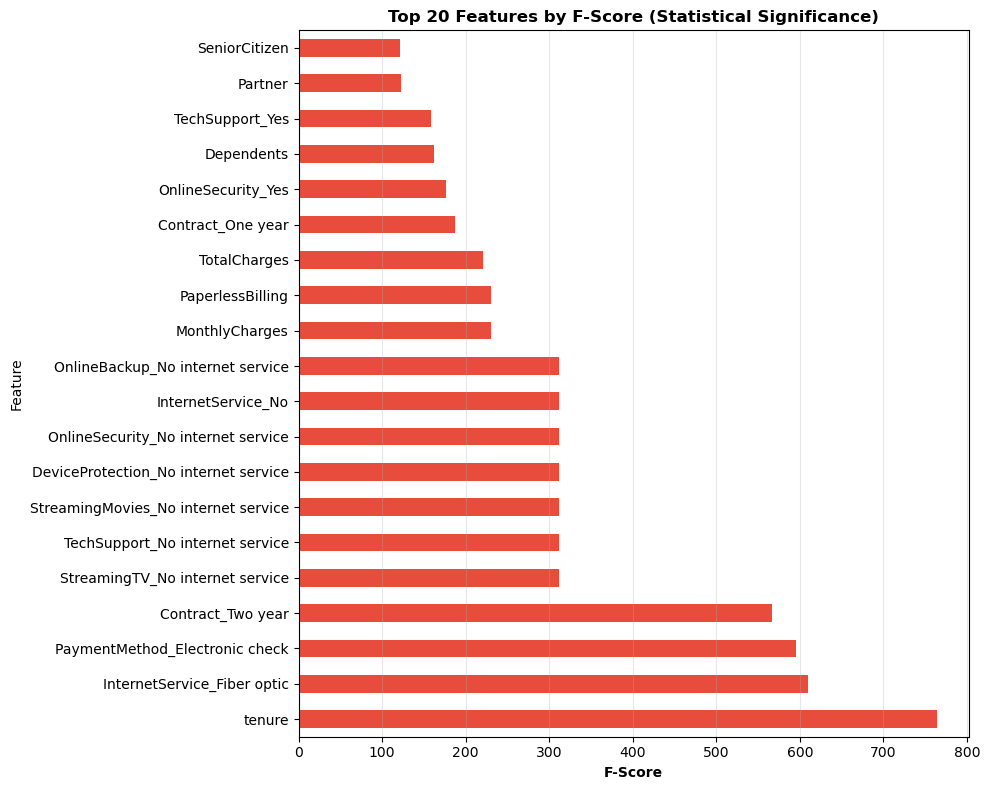

In [15]:
## 3.3 Statistical Tests Feature Selection (SelectKBest)

print("STATISTICAL TESTS - SELECT K BEST FEATURES")

# Use f_classif (ANOVA F-score) for feature selection
selector_kbest = SelectKBest(score_func=f_classif, k=20)
selector_kbest.fit(X_train, y_train)

# Get feature scores
feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': selector_kbest.scores_
}).sort_values('Score', ascending=False)

print("\nTop 20 Features by F-Score (ANOVA):")
print(feature_scores.head(20))

# Get selected features
selected_features_kbest = X_train.columns[selector_kbest.get_support()].tolist()
print(f"\nTop {len(selected_features_kbest)} Selected Features (by F-Score):")
for i, feature in enumerate(selected_features_kbest, 1):
    print(f"  {i:2d}. {feature}")

# Visualize feature scores
fig, ax = plt.subplots(figsize=(10, 8))
feature_scores.head(20).set_index('Feature')['Score'].plot(kind='barh', ax=ax, color='#e74c3c')
ax.set_xlabel('F-Score', fontweight='bold')
ax.set_title('Top 20 Features by F-Score (Statistical Significance)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


TREE-BASED FEATURE IMPORTANCE - RANDOM FOREST

Top 20 Features by Random Forest Importance:
                                  Feature  Importance
8                            TotalCharges    0.201414
7                          MonthlyCharges    0.171837
4                                  tenure    0.166101
28         PaymentMethod_Electronic check    0.042749
11            InternetService_Fiber optic    0.038337
0                                  gender    0.028190
26                      Contract_Two year    0.027359
6                        PaperlessBilling    0.025913
14                     OnlineSecurity_Yes    0.024495
2                                 Partner    0.023026
20                        TechSupport_Yes    0.022940
16                       OnlineBackup_Yes    0.022356
25                      Contract_One year    0.021275
1                           SeniorCitizen    0.021115
10                      MultipleLines_Yes    0.020329
3                              Dependents   

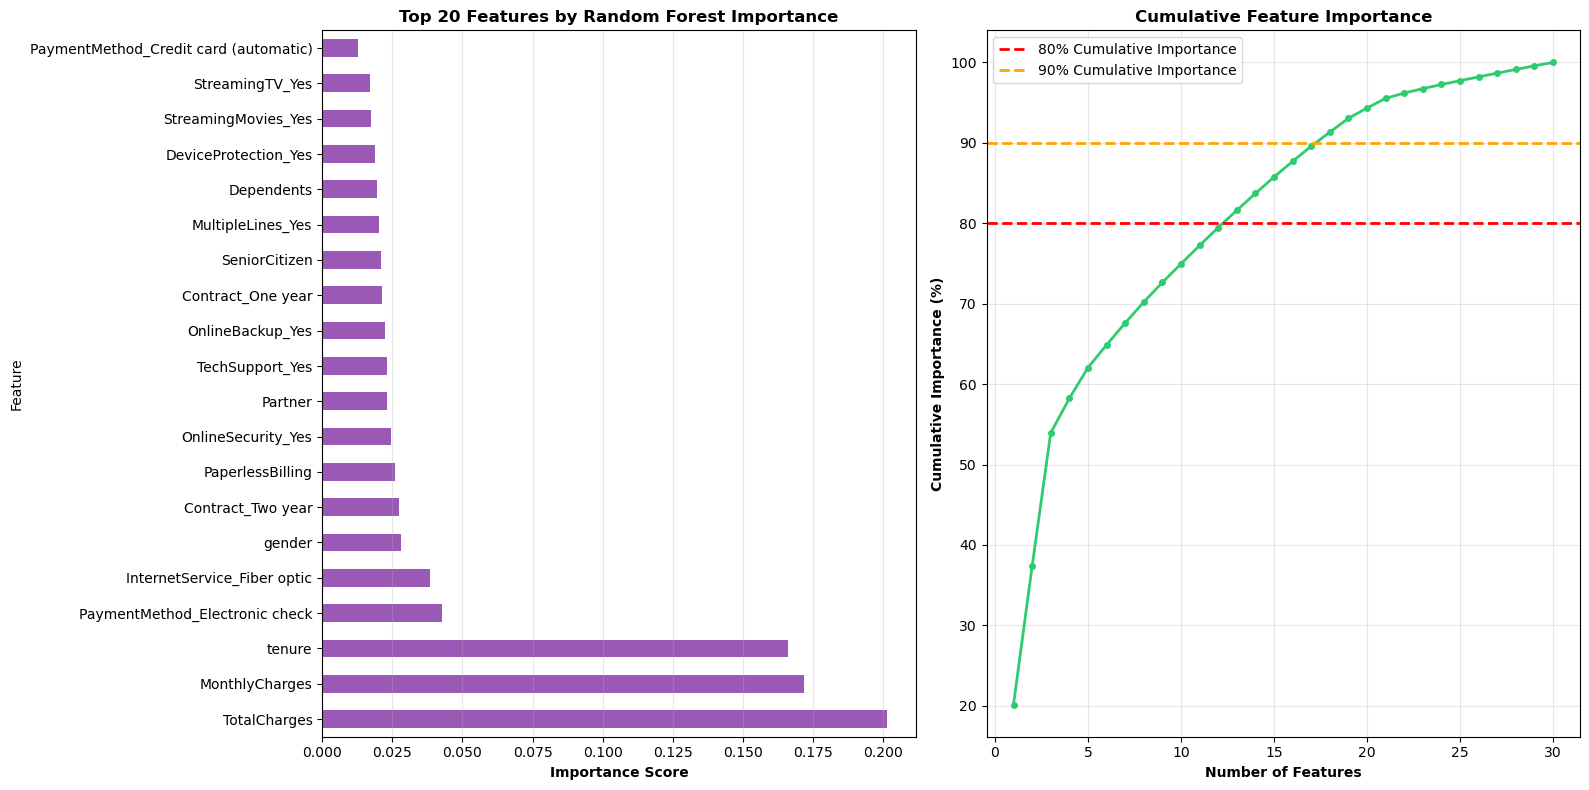


Cumulative Importance:
  - 80% Importance: 13 features
  - 90% Importance: 18 features
  - 100% Importance: 30 features


In [16]:
## 3.4 Tree-Based Feature Importance (Random Forest)

print("TREE-BASED FEATURE IMPORTANCE - RANDOM FOREST")

# Train a Random Forest model to get feature importance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=20)
rf_model.fit(X_train, y_train)

# Get feature importance
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 Features by Random Forest Importance:")
print(rf_importance.head(20))

# Select top features based on importance threshold
importance_threshold = rf_importance['Importance'].quantile(0.75)  # Top 25%
top_features_rf = rf_importance[rf_importance['Importance'] >= importance_threshold]['Feature'].tolist()

print(f"\nImportance Threshold (75th percentile): {importance_threshold:.6f}")
print(f"Features with Importance >= {importance_threshold:.6f}: {len(top_features_rf)} features")
print(f"Features: {top_features_rf}")

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 20 features
rf_importance.head(20).set_index('Feature')['Importance'].plot(kind='barh', ax=axes[0], color='#9b59b6')
axes[0].set_xlabel('Importance Score', fontweight='bold')
axes[0].set_title('Top 20 Features by Random Forest Importance', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Cumulative importance
cumsum = rf_importance['Importance'].cumsum() / rf_importance['Importance'].sum() * 100
axes[1].plot(range(1, len(cumsum) + 1), cumsum.values, marker='o', linestyle='-', color='#2ecc71', linewidth=2, markersize=4)
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=2, label='80% Cumulative Importance')
axes[1].axhline(y=90, color='orange', linestyle='--', linewidth=2, label='90% Cumulative Importance')
axes[1].set_xlabel('Number of Features', fontweight='bold')
axes[1].set_ylabel('Cumulative Importance (%)', fontweight='bold')
axes[1].set_title('Cumulative Feature Importance', fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Find number of features for 80% and 90% importance
cumsum_pct = cumsum.values
n_features_80 = np.argmax(cumsum_pct >= 80) + 1
n_features_90 = np.argmax(cumsum_pct >= 90) + 1

print(f"\nCumulative Importance:")
print(f"  - 80% Importance: {n_features_80} features")
print(f"  - 90% Importance: {n_features_90} features")
print(f"  - 100% Importance: {len(rf_importance)} features")


In [17]:
## 3.5 Recursive Feature Elimination (RFE)

print("RECURSIVE FEATURE ELIMINATION (RFE)")

# Apply RFE with Random Forest estimator to select top features
n_features_to_select = 20
rfe = RFE(estimator=RandomForestClassifier(n_estimators=100, random_state=42, max_depth=20), 
          n_features_to_select=n_features_to_select)
rfe.fit(X_train, y_train)

# Get RFE selected features
rfe_features = X_train.columns[rfe.support_].tolist()

print(f"\nTop {n_features_to_select} Features Selected by RFE:")
for i, feature in enumerate(rfe_features, 1):
    print(f"  {i:2d}. {feature}")

# RFE ranking
rfe_ranking = pd.DataFrame({
    'Feature': X_train.columns,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')

print(f"\nRFE Ranking (Top 20):")
print(rfe_ranking.head(20))



RECURSIVE FEATURE ELIMINATION (RFE)

Top 20 Features Selected by RFE:
   1. gender
   2. SeniorCitizen
   3. Partner
   4. Dependents
   5. tenure
   6. PaperlessBilling
   7. MonthlyCharges
   8. TotalCharges
   9. MultipleLines_Yes
  10. InternetService_Fiber optic
  11. OnlineSecurity_Yes
  12. OnlineBackup_Yes
  13. DeviceProtection_Yes
  14. TechSupport_Yes
  15. StreamingTV_Yes
  16. StreamingMovies_No internet service
  17. StreamingMovies_Yes
  18. Contract_One year
  19. Contract_Two year
  20. PaymentMethod_Electronic check

RFE Ranking (Top 20):
                                Feature  Ranking
0                                gender        1
26                    Contract_Two year        1
25                    Contract_One year        1
24                  StreamingMovies_Yes        1
23  StreamingMovies_No internet service        1
22                      StreamingTV_Yes        1
20                      TechSupport_Yes        1
18                 DeviceProtection_Yes      

FEATURE SELECTION ENSEMBLE CONSENSUS

Feature Selection Consensus (All Methods):
Features selected by multiple methods (higher votes = more methods agree):
                                 Feature  Votes
0                                 tenure      5
11                        MonthlyCharges      5
1            InternetService_Fiber optic      5
12                      PaperlessBilling      5
13                          TotalCharges      5
3                      Contract_Two year      5
2         PaymentMethod_Electronic check      5
16                            Dependents      4
18                               Partner      4
17                       TechSupport_Yes      4
15                    OnlineSecurity_Yes      4
14                     Contract_One year      3
20                                gender      3
19                         SeniorCitizen      3
5    StreamingMovies_No internet service      3
4       OnlineBackup_No internet service      2
6        StreamingTV_No inte

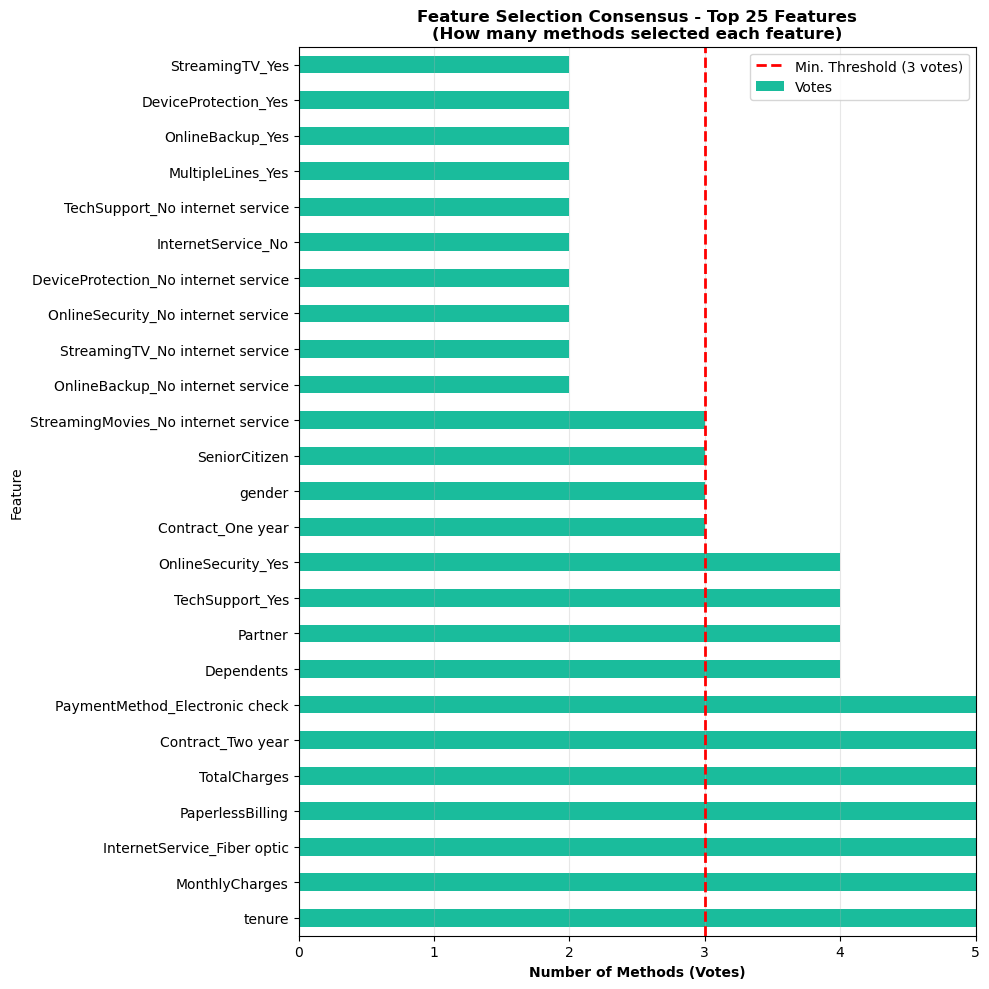

Selection Methods Summary:
Method 1 - Correlation (threshold > 0.05): 20 features
Method 2 - Variance Threshold: 18 features
Method 3 - SelectKBest (F-Score, K=20): 20 features
Method 4 - Random Forest (Top 25%): 8 features
Method 5 - RFE (K=20): 20 features

Consensus Features (Votes >= 3): 15 features


In [18]:
## 3.6 Feature Selection Consensus (Ensemble)

print("FEATURE SELECTION ENSEMBLE CONSENSUS")

# Combine all feature selection methods
feature_selection_votes = {}

# Method 1: Correlation (features with correlation > threshold)
for feature in highly_correlated_features:
    feature_selection_votes[feature] = feature_selection_votes.get(feature, 0) + 1

# Method 2: High Variance features
for feature in high_variance_features:
    feature_selection_votes[feature] = feature_selection_votes.get(feature, 0) + 1

# Method 3: SelectKBest (top 20)
for feature in selected_features_kbest:
    feature_selection_votes[feature] = feature_selection_votes.get(feature, 0) + 1

# Method 4: Random Forest Top Features
for feature in top_features_rf:
    feature_selection_votes[feature] = feature_selection_votes.get(feature, 0) + 1

# Method 5: RFE Selected Features
for feature in rfe_features:
    feature_selection_votes[feature] = feature_selection_votes.get(feature, 0) + 1

# Sort by voting count
consensus_ranking = pd.DataFrame({
    'Feature': list(feature_selection_votes.keys()),
    'Votes': list(feature_selection_votes.values())
}).sort_values('Votes', ascending=False)

print("\nFeature Selection Consensus (All Methods):")
print("Features selected by multiple methods (higher votes = more methods agree):")
print(consensus_ranking)

# Select features with at least 3 votes (agreed by at least 3 methods)
min_votes = 3
consensus_features = consensus_ranking[consensus_ranking['Votes'] >= min_votes]['Feature'].tolist()

print(f"\n Final Selected Features (agreed by at least {min_votes} methods):")
print(f"  Count: {len(consensus_features)} features")
print(f"  Features: {consensus_features}")

# Create datasets using selected features
X_train_selected = X_train[consensus_features]
X_test_selected = X_test[consensus_features]

print("Training Shape:", X_train_selected.shape)
print("Testing Shape:", X_test_selected.shape)

# Visualize consensus
fig, ax = plt.subplots(figsize=(10, 10))
consensus_ranking.head(25).set_index('Feature')['Votes'].plot(kind='barh', ax=ax, color='#1abc9c')
ax.set_xlabel('Number of Methods (Votes)', fontweight='bold')
ax.set_title('Feature Selection Consensus - Top 25 Features\n(How many methods selected each feature)', fontweight='bold')
ax.set_xlim(0, 5)
ax.grid(axis='x', alpha=0.3)

# Add threshold line
ax.axvline(x=min_votes, color='red', linestyle='--', linewidth=2, label=f'Min. Threshold ({min_votes} votes)')
ax.legend()

plt.tight_layout()
plt.show()

# Summary of selection methods
print("Selection Methods Summary:")
print(f"Method 1 - Correlation (threshold > {correlation_threshold}): {len(highly_correlated_features)} features")
print(f"Method 2 - Variance Threshold: {len(high_variance_features)} features")
print(f"Method 3 - SelectKBest (F-Score, K=20): {len(selected_features_kbest)} features")
print(f"Method 4 - Random Forest (Top 25%): {len(top_features_rf)} features")
print(f"Method 5 - RFE (K=20): {len(rfe_features)} features")
print(f"\nConsensus Features (Votes >= {min_votes}): {len(consensus_features)} features")


SELECTED FEATURES DETAILED ANALYSIS

Correlation of Selected Features with Churn:
InternetService_Fiber optic            0.312656
PaymentMethod_Electronic check         0.309214
MonthlyCharges                         0.198040
PaperlessBilling                       0.197981
Partner                                0.145717
SeniorCitizen                          0.145599
gender                                -0.002208
TechSupport_Yes                       -0.165723
Dependents                            -0.167459
OnlineSecurity_Yes                    -0.174581
Contract_One year                     -0.179467
TotalCharges                          -0.194403
StreamingMovies_No internet service   -0.228929
Contract_Two year                     -0.302209
tenure                                -0.345593
dtype: float64

Random Forest Importance for Selected Features:
                                Feature  Importance
8                          TotalCharges    0.201414
7                        Month

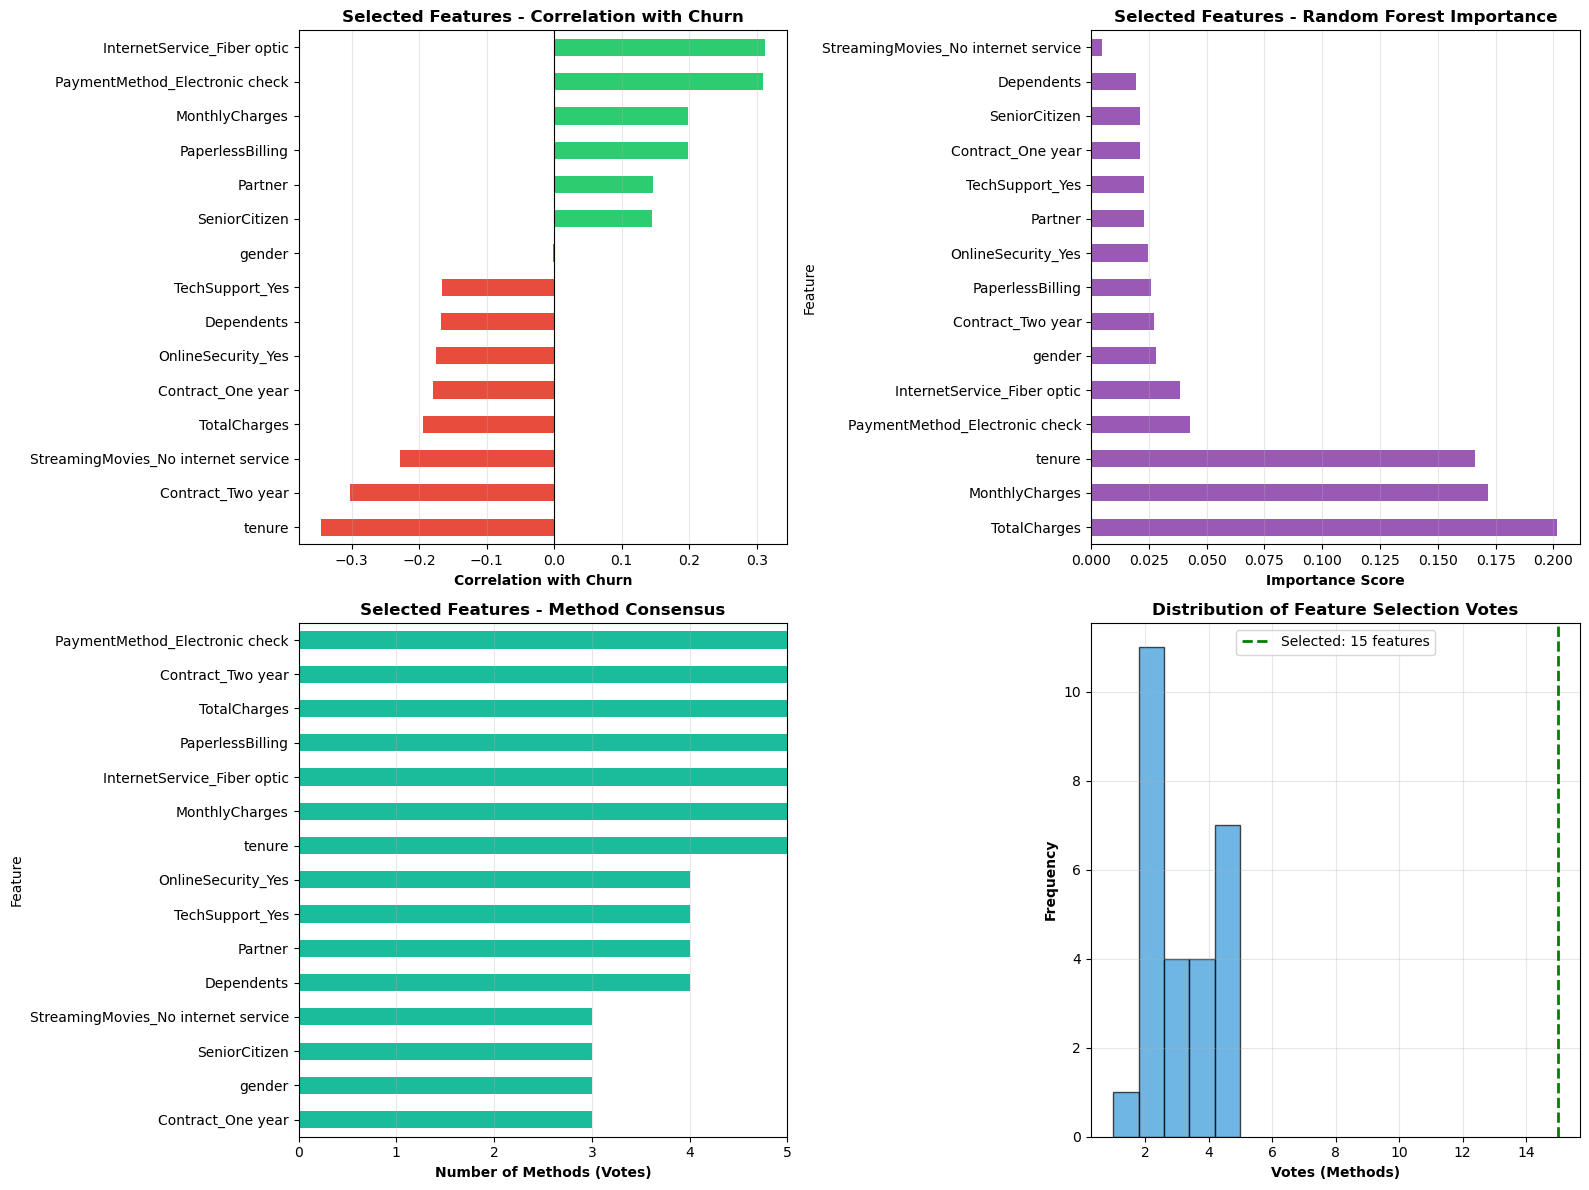

In [19]:
## 3.7 Feature Analysis & Visualization (Consensus Features)

print("SELECTED FEATURES DETAILED ANALYSIS")

# Analyze the correlation of selected features with target
selected_correlations = X_train[consensus_features].corrwith(y_train).sort_values(ascending=False)

print("\nCorrelation of Selected Features with Churn:")
print(selected_correlations)

# Feature importance for selected features
selected_rf_importance = rf_importance[rf_importance['Feature'].isin(consensus_features)].sort_values('Importance', ascending=False)

print("\nRandom Forest Importance for Selected Features:")
print(selected_rf_importance)

# Visualize selected features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Correlation of selected features
selected_correlations_sorted = selected_correlations.sort_values()
colors_corr = ['#e74c3c' if x < 0 else '#2ecc71' for x in selected_correlations_sorted.values]
selected_correlations_sorted.plot(kind='barh', ax=axes[0, 0], color=colors_corr)
axes[0, 0].set_xlabel('Correlation with Churn', fontweight='bold')
axes[0, 0].set_title('Selected Features - Correlation with Churn', fontweight='bold')
axes[0, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Feature importance of selected features
selected_rf_importance.set_index('Feature')['Importance'].plot(kind='barh', ax=axes[0, 1], color='#9b59b6')
axes[0, 1].set_xlabel('Importance Score', fontweight='bold')
axes[0, 1].set_title('Selected Features - Random Forest Importance', fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Selection method votes
consensus_ranking_selected = consensus_ranking[consensus_ranking['Feature'].isin(consensus_features)]
consensus_ranking_selected.set_index('Feature')['Votes'].sort_values(ascending=True).plot(kind='barh', ax=axes[1, 0], color='#1abc9c')
axes[1, 0].set_xlabel('Number of Methods (Votes)', fontweight='bold')
axes[1, 0].set_title('Selected Features - Method Consensus', fontweight='bold')
axes[1, 0].set_xlim(0, 5)
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Distribution of votes
axes[1, 1].hist(consensus_ranking['Votes'], bins=5, edgecolor='black', color='#3498db', alpha=0.7)
axes[1, 1].axvline(x=len(consensus_features), color='green', linestyle='--', linewidth=2, label=f'Selected: {len(consensus_features)} features')
axes[1, 1].set_xlabel('Votes (Methods)', fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontweight='bold')
axes[1, 1].set_title('Distribution of Feature Selection Votes', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Task 4: Model Training ,Model Evaluation and Model Selection

### Three classification algorithms were selected for churn prediction:
### Logistic Regression : Simple baseline model for binary classification.
### Decision Tree : Easy to interpret and captures decision rules.
### Random Forest : Ensemble model that improves accuracy and reduces overfitting.

In [93]:
## 4.1 Import Required Libraries for Model Training and Evaluation

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [94]:
## 4.2 Train Logistic Regression Model

print("MODEL 1: LOGISTIC REGRESSION")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

# Initialize and train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')
lr_model.fit(X_train_selected, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_selected)
y_pred_proba_lr = lr_model.predict_proba(X_test_selected)[:, 1]

print("\n Logistic Regression Model Trained Successfully")
print(f"  Model Parameters: max_iter=1000, solver='lbfgs', random_state=42")
print(f"  Number of Features: {len(consensus_features)}")
print(f"  Training Set Size: {X_train_selected.shape[0]}")
print(f"  Testing Set Size: {X_test_selected.shape[0]}")

# Calculate metrics for Logistic Regression
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_pred_proba_lr)

print(f"\n✓ LOGISTIC REGRESSION - PERFORMANCE METRICS:")
print(f"  Accuracy:  {lr_accuracy:.4f}")
print(f"  Precision: {lr_precision:.4f}")
print(f"  Recall:    {lr_recall:.4f}")
print(f"  F1-Score:  {lr_f1:.4f}")
print(f"  ROC-AUC:   {lr_roc_auc:.4f}")

# Store results
lr_results = {
    'Model': 'Logistic Regression',
    'Accuracy': lr_accuracy,
    'Precision': lr_precision,
    'Recall': lr_recall,
    'F1-Score': lr_f1,
    'ROC-AUC': lr_roc_auc
}

print("\n Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))


MODEL 1: LOGISTIC REGRESSION

 Logistic Regression Model Trained Successfully
  Model Parameters: max_iter=1000, solver='lbfgs', random_state=42
  Number of Features: 15
  Training Set Size: 5634
  Testing Set Size: 1409

✓ LOGISTIC REGRESSION - PERFORMANCE METRICS:
  Accuracy:  0.7999
  Precision: 0.6474
  Recall:    0.5401
  F1-Score:  0.5889
  ROC-AUC:   0.8401

 Classification Report - Logistic Regression:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.65      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [95]:
## 4.3 Train Decision Tree Model

print("MODEL 2: DECISION TREE")

# Initialize and train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train_selected, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test_selected)
y_pred_proba_dt = dt_model.predict_proba(X_test_selected)[:, 1]

print("\n✓ Decision Tree Model Trained Successfully")
print(f"  Model Parameters: max_depth=10, random_state=42")
print(f"  Number of Features: {len(consensus_features)}")
print(f"  Training Set Size: {X_train_selected.shape[0]}")
print(f"  Testing Set Size: {X_test_selected.shape[0]}")

# Calculate metrics for Decision Tree
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_roc_auc = roc_auc_score(y_test, y_pred_proba_dt)

print(f"\n DECISION TREE - PERFORMANCE METRICS:")
print(f"  Accuracy:  {dt_accuracy:.4f}")
print(f"  Precision: {dt_precision:.4f}")
print(f"  Recall:    {dt_recall:.4f}")
print(f"  F1-Score:  {dt_f1:.4f}")
print(f"  ROC-AUC:   {dt_roc_auc:.4f}")

# Store results
dt_results = {
    'Model': 'Decision Tree',
    'Accuracy': dt_accuracy,
    'Precision': dt_precision,
    'Recall': dt_recall,
    'F1-Score': dt_f1,
    'ROC-AUC': dt_roc_auc
}

print("\n Classification Report - Decision Tree:")
print(classification_report(y_test, y_pred_dt, target_names=['No Churn', 'Churn']))


MODEL 2: DECISION TREE

✓ Decision Tree Model Trained Successfully
  Model Parameters: max_depth=10, random_state=42
  Number of Features: 15
  Training Set Size: 5634
  Testing Set Size: 1409

 DECISION TREE - PERFORMANCE METRICS:
  Accuracy:  0.7608
  Precision: 0.5533
  Recall:    0.5134
  F1-Score:  0.5326
  ROC-AUC:   0.7732

 Classification Report - Decision Tree:
              precision    recall  f1-score   support

    No Churn       0.83      0.85      0.84      1035
       Churn       0.55      0.51      0.53       374

    accuracy                           0.76      1409
   macro avg       0.69      0.68      0.69      1409
weighted avg       0.76      0.76      0.76      1409



In [96]:
## 4.4 Train Random Forest Model

print("MODEL 3: RANDOM FOREST")

# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1)
rf_model.fit(X_train_selected, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_selected)
y_pred_proba_rf = rf_model.predict_proba(X_test_selected)[:, 1]

print("\n✓ Random Forest Model Trained Successfully")
print(f"  Model Parameters: n_estimators=100, max_depth=15, random_state=42")
print(f"  Number of Features: {len(consensus_features)}")
print(f"  Training Set Size: {X_train_selected.shape[0]}")
print(f"  Testing Set Size: {X_test_selected.shape[0]}")

# Calculate metrics for Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

print(f"\n RANDOM FOREST - PERFORMANCE METRICS:")
print(f"  Accuracy:  {rf_accuracy:.4f}")
print(f"  Precision: {rf_precision:.4f}")
print(f"  Recall:    {rf_recall:.4f}")
print(f"  F1-Score:  {rf_f1:.4f}")
print(f"  ROC-AUC:   {rf_roc_auc:.4f}")

# Store results
rf_results = {
    'Model': 'Random Forest',
    'Accuracy': rf_accuracy,
    'Precision': rf_precision,
    'Recall': rf_recall,
    'F1-Score': rf_f1,
    'ROC-AUC': rf_roc_auc
}

print("\n Classification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))


MODEL 3: RANDOM FOREST

✓ Random Forest Model Trained Successfully
  Model Parameters: n_estimators=100, max_depth=15, random_state=42
  Number of Features: 15
  Training Set Size: 5634
  Testing Set Size: 1409

 RANDOM FOREST - PERFORMANCE METRICS:
  Accuracy:  0.7956
  Precision: 0.6424
  Recall:    0.5187
  F1-Score:  0.5740
  ROC-AUC:   0.8237

 Classification Report - Random Forest:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.64      0.52      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [97]:
## 4.5 Compare All Models Performance

print("MODEL COMPARISON & PERFORMANCE ANALYSIS")

# Create comparison DataFrame
results_df = pd.DataFrame([lr_results, dt_results, rf_results])

print("\n PERFORMANCE METRICS COMPARISON TABLE:")
print(results_df.to_string(index=False))

# Identify best model for each metric
print("BEST MODELS BY METRIC:")

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
for metric in metrics:
    best_idx = results_df[metric].idxmax()
    best_model = results_df.loc[best_idx, 'Model']
    best_value = results_df.loc[best_idx, metric]
    print(f"  {metric:12s}: {best_model:20s} ({best_value:.4f})")

# Overall best model (based on average of all metrics)
results_df['Average_Score'] = results_df[metrics].mean(axis=1)
best_overall_idx = results_df['Average_Score'].idxmax()
best_overall_model = results_df.loc[best_overall_idx, 'Model']
best_overall_score = results_df.loc[best_overall_idx, 'Average_Score']

print(f"✓ BEST OVERALL MODEL: {best_overall_model}")
print(f"  Average Score Across All Metrics: {best_overall_score:.4f}")

# Model rankings
print("\n MODEL RANKINGS (by Average Score):")
rankings = results_df[['Model', 'Average_Score']].sort_values('Average_Score', ascending=False).reset_index(drop=True)
for idx, row in rankings.iterrows():
    print(f"  {idx + 1}. {row['Model']:20s} - Average Score: {row['Average_Score']:.4f}")



MODEL COMPARISON & PERFORMANCE ANALYSIS

 PERFORMANCE METRICS COMPARISON TABLE:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.799858   0.647436 0.540107  0.588921 0.840135
      Decision Tree  0.760823   0.553314 0.513369  0.532594 0.773218
      Random Forest  0.795600   0.642384 0.518717  0.573964 0.823652
BEST MODELS BY METRIC:
  Accuracy    : Logistic Regression  (0.7999)
  Precision   : Logistic Regression  (0.6474)
  Recall      : Logistic Regression  (0.5401)
  F1-Score    : Logistic Regression  (0.5889)
  ROC-AUC     : Logistic Regression  (0.8401)
✓ BEST OVERALL MODEL: Logistic Regression
  Average Score Across All Metrics: 0.6833

 MODEL RANKINGS (by Average Score):
  1. Logistic Regression  - Average Score: 0.6833
  2. Random Forest        - Average Score: 0.6709
  3. Decision Tree        - Average Score: 0.6267


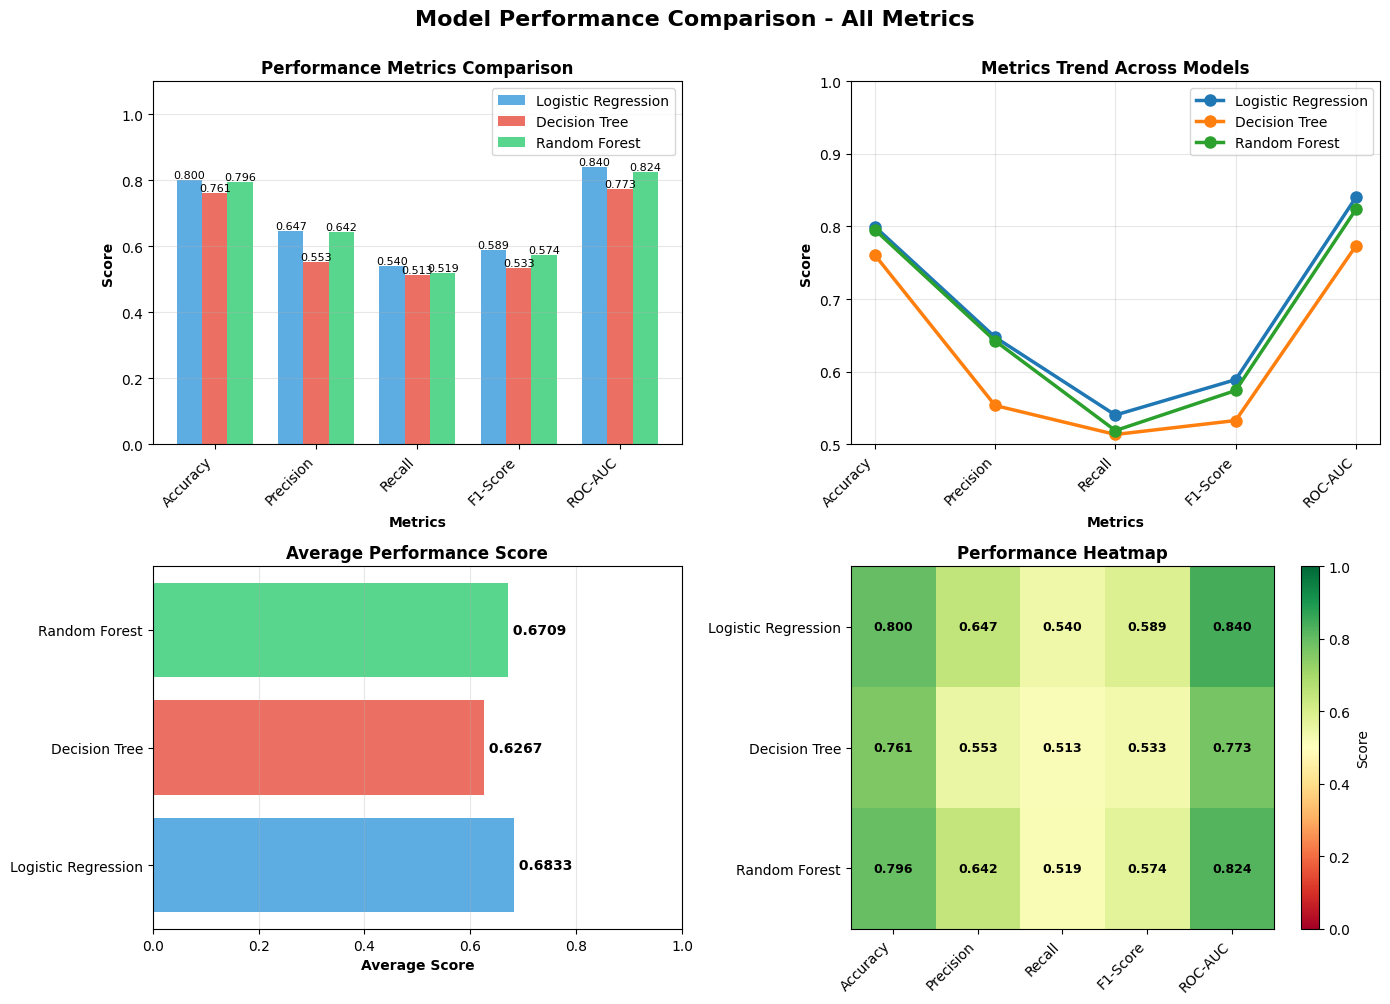


 Visualization created successfully!


In [ ]:
## 4.6 Visualize Model Performance Comparison

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison - All Metrics', fontsize=16, fontweight='bold', y=1.00)

# 1. Grouped Bar Chart - All Metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.25

ax = axes[0, 0]
bars1 = ax.bar(x - width, results_df.loc[0, metrics_to_plot], width, label='Logistic Regression', color='#3498db', alpha=0.8)
bars2 = ax.bar(x, results_df.loc[1, metrics_to_plot], width, label='Decision Tree', color='#e74c3c', alpha=0.8)
bars3 = ax.bar(x + width, results_df.loc[2, metrics_to_plot], width, label='Random Forest', color='#2ecc71', alpha=0.8)

ax.set_xlabel('Metrics', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Performance Metrics Comparison', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# 2. Line Plot - Metrics Trend
ax = axes[0, 1]
for idx, row in results_df.iterrows():
    model_name = row['Model']
    values = row[metrics_to_plot].values
    ax.plot(metrics_to_plot, values, marker='o', linewidth=2.5, markersize=8, label=model_name)

ax.set_xlabel('Metrics', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Metrics Trend Across Models', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.5, 1.0)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. Average Score Comparison
ax = axes[1, 0]
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = ax.barh(results_df['Model'], results_df['Average_Score'], color=colors, alpha=0.8)
ax.set_xlabel('Average Score', fontweight='bold')
ax.set_title('Average Performance Score', fontweight='bold')
ax.set_xlim(0, 1)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for idx, (bar, val) in enumerate(zip(bars, results_df['Average_Score'])):
    ax.text(val, idx, f' {val:.4f}', va='center', fontweight='bold')

# 4. Radar-like comparison (Heatmap)
ax = axes[1, 1]
comparison_matrix = results_df[metrics_to_plot].values
im = ax.imshow(comparison_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(np.arange(len(metrics_to_plot)))
ax.set_yticks(np.arange(len(results_df)))
ax.set_xticklabels(metrics_to_plot, rotation=45, ha='right')
ax.set_yticklabels(results_df['Model'])
ax.set_title('Performance Heatmap', fontweight='bold')

# Add text annotations
for i in range(len(results_df)):
    for j in range(len(metrics_to_plot)):
        text = ax.text(j, i, f'{comparison_matrix[i, j]:.3f}',
                      ha="center", va="center", color="black", fontweight='bold', fontsize=9)

plt.colorbar(im, ax=ax, label='Score')

plt.tight_layout()
plt.show()



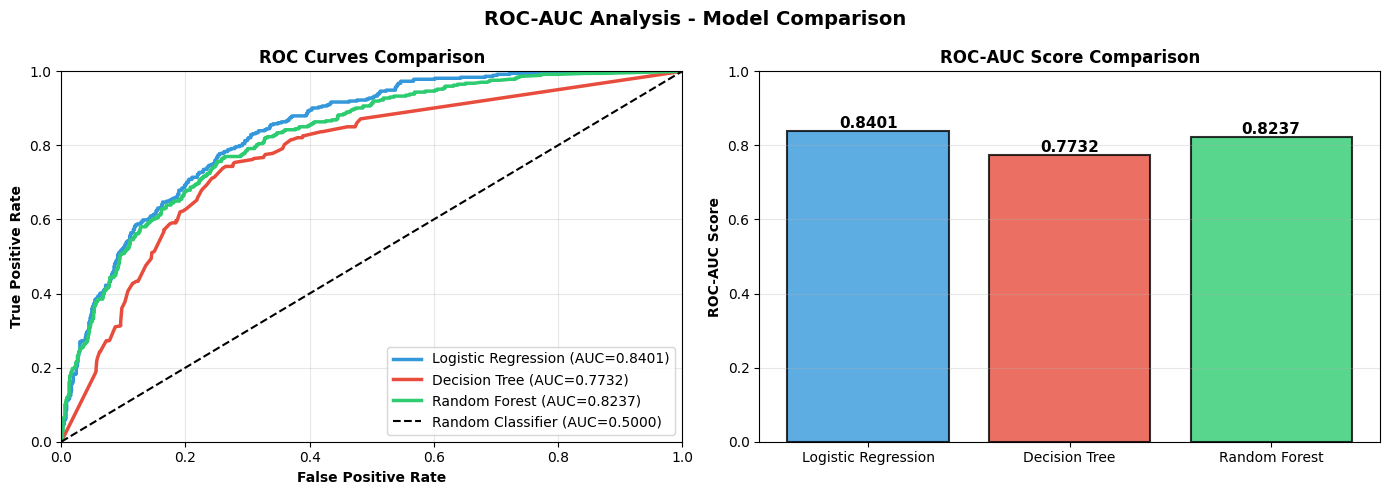

In [99]:
## 4.7 ROC-AUC Curves Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ROC-AUC Analysis - Model Comparison', fontsize=14, fontweight='bold')

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

# Plot 1: ROC Curves
ax = axes[0]
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_roc_auc:.4f})', linewidth=2.5, color='#3498db')
ax.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={dt_roc_auc:.4f})', linewidth=2.5, color='#e74c3c')
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_roc_auc:.4f})', linewidth=2.5, color='#2ecc71')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC=0.5000)')

ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('ROC Curves Comparison', fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Plot 2: Confusion Matrices
ax = axes[1]
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
predictions = [y_pred_lr, y_pred_dt, y_pred_rf]
auc_scores = [lr_roc_auc, dt_roc_auc, rf_roc_auc]

# Create a bar chart showing ROC-AUC scores
colors_roc = ['#3498db', '#e74c3c', '#2ecc71']
bars = ax.bar(models, auc_scores, color=colors_roc, alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_ylabel('ROC-AUC Score', fontweight='bold')
ax.set_title('ROC-AUC Score Comparison', fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, auc_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()



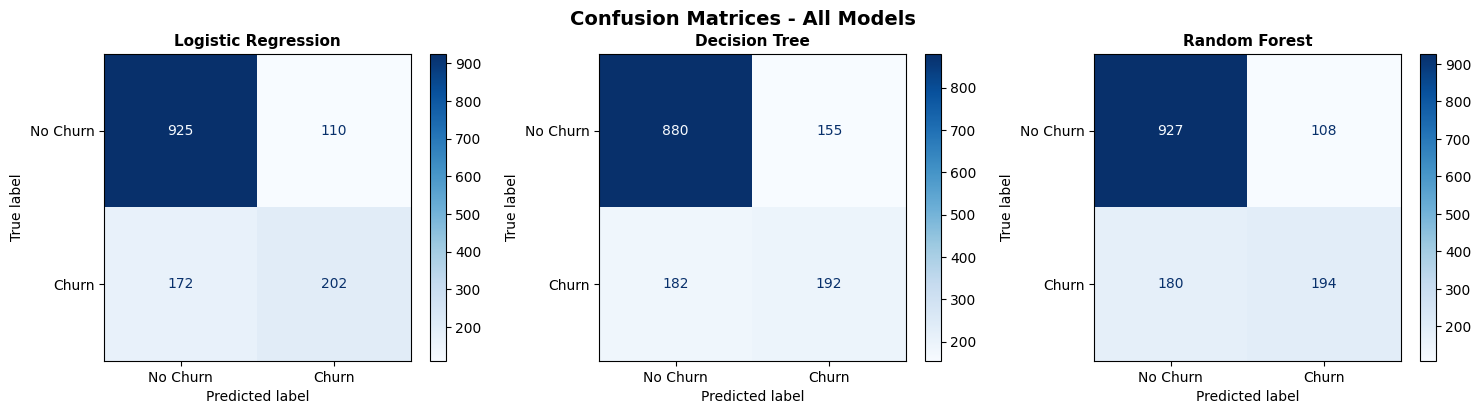

[[927 108]
 [180 194]]


In [ ]:
## 4.8 Confusion Matrices Visualization

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold')

# Confusion matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot confusion matrices
models_conf = ['Logistic Regression', 'Decision Tree', 'Random Forest']
cms = [cm_lr, cm_dt, cm_rf]

for idx, (ax, cm, model) in enumerate(zip(axes, cms, models_conf)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(model, fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()




In [101]:
## 4.9 Final Model Selection and Summary

print("FINAL MODEL SELECTION SUMMARY")

# Determine best model based on different criteria
print("\n1. BEST MODEL BY INDIVIDUAL METRICS:")

best_models = {}
for metric in metrics:
    best_idx = results_df[metric].idxmax()
    best_model = results_df.loc[best_idx, 'Model']
    best_value = results_df.loc[best_idx, metric]
    best_models[metric] = best_model
    symbol = "✓" if results_df.loc[best_idx, metric] == results_df[metric].max() else " "
    print(f"  {symbol} {metric:12s}: {best_model:20s} - {best_value:.4f}")

# Count wins for each model
print("\n2. MODEL PERFORMANCE RANKING:")
from collections import Counter
model_wins = Counter(best_models.values())

ranking = sorted(model_wins.items(), key=lambda x: x[1], reverse=True)
for rank, (model, wins) in enumerate(ranking, 1):
    avg_score = results_df[results_df['Model'] == model]['Average_Score'].values[0]
    print(f"  #{rank} - {model:20s}: {wins} metric(s) won | Avg Score: {avg_score:.4f}")

# Final recommendation
print("\n3. FINAL RECOMMENDATION:")

best_idx = results_df['Average_Score'].idxmax()
selected_model = results_df.loc[best_idx, 'Model']
selected_scores = results_df.loc[best_idx, metrics].to_dict()

print(f"\n   SELECTED MODEL: {selected_model.upper()}")
print(f"\n  Performance Metrics:")
for metric in metrics:
    print(f"    • {metric:12s}: {selected_scores[metric]:.4f}")

print(f"\n  Model Details:")
if selected_model == 'Logistic Regression':
    print(f"    • Algorithm: Linear binary classification")
    print(f"    • Hyperparameters: max_iter=1000, solver='lbfgs'")
    print(f"    • Advantages: Interpretable, fast, low computational cost")
    print(f"    • Best for: When interpretability and speed are important")
    best_model_obj = lr_model
    
elif selected_model == 'Decision Tree':
    print(f"    • Algorithm: Non-parametric tree-based model")
    print(f"    • Hyperparameters: max_depth=10")
    print(f"    • Advantages: Easy to understand, handles non-linear patterns")
    print(f"    • Best for: Interpretable classification with feature importance")
    best_model_obj = dt_model
    
else:  # Random Forest
    print(f"    • Algorithm: Ensemble of decision trees")
    print(f"    • Hyperparameters: n_estimators=100, max_depth=15")
    print(f"    • Advantages: Robust, handles complex patterns, reduces overfitting")
    print(f"    • Best for: Best overall performance with reduced variance")
    best_model_obj = rf_model

# Model comparison summary
print("\n4. COMPARATIVE ANALYSIS:")

print(f"\n  Accuracy Analysis:")
max_acc = results_df['Accuracy'].max()
min_acc = results_df['Accuracy'].min()
acc_diff = max_acc - min_acc
print(f"    • Best:  {results_df.loc[results_df['Accuracy'].idxmax(), 'Model']:20s} - {max_acc:.4f}")
print(f"    • Worst: {results_df.loc[results_df['Accuracy'].idxmin(), 'Model']:20s} - {min_acc:.4f}")
print(f"    • Difference: {acc_diff:.4f}")

print(f"\n  Precision vs Recall Trade-off:")
for idx, row in results_df.iterrows():
    print(f"    • {row['Model']:20s}: Precision={row['Precision']:.4f}, Recall={row['Recall']:.4f}")

print(f"\n  ROC-AUC Analysis:")
max_auc = results_df['ROC-AUC'].max()
best_auc_model = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
print(f"    • Best ROC-AUC: {best_auc_model} - {max_auc:.4f}")
print(f"    • Indicates probability prediction capability")

# Recommendation for deployment
print("\n5. DEPLOYMENT RECOMMENDATION:")
print(f"\n  The {selected_model.upper()} model is recommended for deployment because:")
print(f"     Highest average performance across all metrics ({results_df.loc[best_idx, 'Average_Score']:.4f})")
print(f"     Balanced accuracy ({results_df.loc[best_idx, 'Accuracy']:.4f}) and ROC-AUC ({results_df.loc[best_idx, 'ROC-AUC']:.4f})")
print(f"     Good precision ({results_df.loc[best_idx, 'Precision']:.4f}) and recall ({results_df.loc[best_idx, 'Recall']:.4f})")


FINAL MODEL SELECTION SUMMARY

1. BEST MODEL BY INDIVIDUAL METRICS:
  ✓ Accuracy    : Logistic Regression  - 0.7999
  ✓ Precision   : Logistic Regression  - 0.6474
  ✓ Recall      : Logistic Regression  - 0.5401
  ✓ F1-Score    : Logistic Regression  - 0.5889
  ✓ ROC-AUC     : Logistic Regression  - 0.8401

2. MODEL PERFORMANCE RANKING:
  #1 - Logistic Regression : 5 metric(s) won | Avg Score: 0.6833

3. FINAL RECOMMENDATION:

   SELECTED MODEL: LOGISTIC REGRESSION

  Performance Metrics:
    • Accuracy    : 0.7999
    • Precision   : 0.6474
    • Recall      : 0.5401
    • F1-Score    : 0.5889
    • ROC-AUC     : 0.8401

  Model Details:
    • Algorithm: Linear binary classification
    • Hyperparameters: max_iter=1000, solver='lbfgs'
    • Advantages: Interpretable, fast, low computational cost
    • Best for: When interpretability and speed are important

4. COMPARATIVE ANALYSIS:

  Accuracy Analysis:
    • Best:  Logistic Regression  - 0.7999
    • Worst: Decision Tree        - 0.7